# Resolução do Desafio

## Questão 1
### Parte 1 — Visão geral do dataset

In [17]:
import pandas as pd

df = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Informações do dataset
df.info()

# Quantidade total de linhas
print(f'Quantidade total de linhas: {df.shape[0]}')

# Quantidade total de colunas
print(f'Quantidade total de colunas: {df.shape[1]}')

# Intervalo de datas analisado (data mínima e máxima)
data_min = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True).min()
data_max = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True).max()
print(f'Data mínima: {data_min}')
print(f'Data máxima: {data_max}')

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 464.0 KB
Quantidade total de linhas: 9895
Quantidade total de colunas: 6
Data mínima: 2023-01-01 00:00:00
Data máxima: 2024-12-31 00:00:00


### Parte 2 — Análise de valores numéricos

In [18]:
# Para a coluna "total", calcule:
print(f"Valor mínimo: {df['total'].min():.2f}")
print(f"Valor máximo: {df['total'].max():.2f}")
print(f"Valor médio: {df['total'].mean():.2f}")


Valor mínimo: 294.50
Valor máximo: 2222973.00
Valor médio: 263797.83


## Questão 1.1 - SQL
Código calculando:
- Quantidade total de linhas
- Quantidade total de colunas
- Intervalo de datas analisado (data mínima e máxima)
- Valor mínimo
- Valor máximo
- Valor médio

In [19]:
import duckdb

query = """
SELECT 
    COUNT(*) AS total_linhas,
    MIN(COALESCE(TRY_CAST(sale_date AS DATE), CAST(strptime(sale_date, '%d-%m-%Y') AS DATE))) AS data_minima,
    MAX(COALESCE(TRY_CAST(sale_date AS DATE), CAST(strptime(sale_date, '%d-%m-%Y') AS DATE))) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    AVG(total) AS valor_medio
FROM df; 
"""

resultado_sql = duckdb.query(query).to_df()

display(resultado_sql)

,total_linhas,data_minima,data_maxima,valor_minimo,valor_maximo,valor_medio
0,9895,2023-01-01,2024-12-31,294.5,2222973.0,263797.828267


## Código para colar na plataforma 1.1

In [20]:
SELECT 
    (SELECT COUNT(*) FROM vendas_2023_2024) AS total_linhas,
    (SELECT COUNT(*) FROM information_schema.columns WHERE table_name = 'vendas_2023_2024') AS total_colunas,
    MIN(sale_date) AS data_minima,
    MAX(sale_date) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    AVG(total) AS valor_medio
FROM vendas_2023_2024;


IndentationError: unexpected indent (3869995623.py, line 2)

## Questão 1.2 - Validação
Qual é o valor máximo registrado na coluna "total"? 

**Resposta**: O valor máximo registrado na coluna "total" do dataset de vendas é de 2.222.973,00 (ou 2222973.0).

## Questão 1.3 - Interpretação

- **Possíveis outliers em "total":** Há um forte indício de outliers. A média da coluna (~263.797,83) é substancialmente maior que a sua mediana (50% que gira em torno de 82.225,00), e o valor máximo atinge mais de 2,2 milhões. Essa forte assimetria mostra que a grande maioria das vendas concentra-se em valores muito mais baixos, com poucos registros excepcionais e altos que distorcem as médias e as conclusões analíticas.
- **Qualidade dos dados:** Não constam valores nulos/ausentes em nenhuma das colunas (`id`, `id_client`, `id_product`, `qtd`, `total`, `sale_date`). Contudo, há um problema severo de **inconsistência na formatação** da coluna de datas (`sale_date`). Existem tanto registros no formato "YYYY-MM-DD" (como 2023-09-10) quanto no formato "DD-MM-YYYY" (como 15-09-2024), causando ambiguidade, o que poderia levar um leitor desavisado ou um sistema de ingestão a inverter dias por meses se não parametrizado perfeitamente.
- **O dataset está pronto?** **O dataset não está pronto para uso analítico avançado**. Ele exigiria tratamento prévio para: (1) padronizar e assegurar os tipos de data de `sale_date` (ex: tudo para o formato YYYY-MM-DD em datetime64 ISO-8601), (2) decidir qual a melhor abordagem para os outliers (remoção ou estudo como vendas diferenciadas - ex: B2B vs B2C) e (3) validar com os especialistas do negócio quais regras podem prevenir esses registros mistos e inflados se originados por erro.

---
## Questão 2 - Produtos
### 2.1 Normalização de dados

In [ ]:
import pandas as pd

# Carregando o dataset
df_produtos = pd.read_csv('../data/raw/produtos_raw.csv')

# Parte 1 — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.
def padronizar_categoria(cat):
    cat_lower = str(cat).lower().replace(' ', '').replace('ô', 'o').replace('ã', 'a').replace('ç', 'c')
    if 'eletr' in cat_lower:
        return 'eletrônicos'
    elif 'prop' in cat_lower:
        return 'propulsão'
    elif 'cor' in cat_lower or 'enc' in cat_lower:
        return 'ancoragem'
    return cat

df_produtos['actual_category'] = df_produtos['actual_category'].apply(padronizar_categoria)
print("Categorias padronizadas:", df_produtos['actual_category'].unique())

# Parte 2 — Converta os valores para o tipo numérico.
df_produtos['price'] = df_produtos['price'].str.replace('R$ ', '', regex=False).astype(float)
print("Tipos de dados após conversão:")
print(df_produtos.dtypes)

# Parte 3 — Remova as duplicatas.
qtd_antes = len(df_produtos)
df_produtos = df_produtos.drop_duplicates()
qtd_depois = len(df_produtos)

print(f"Registros antes: {qtd_antes} | Registros depois (sem duplicatas): {qtd_depois}")

# Visualizando o resultado final
display(df_produtos.head(10))

Categorias padronizadas: <StringArray>
['eletrônicos', 'propulsão', 'ancoragem']
Length: 3, dtype: str
Tipos de dados após conversão:
name                   str
price              float64
code                 int64
actual_category        str
dtype: object
Registros antes: 157 | Registros depois (sem duplicatas): 150


,name,price,code,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,eletrônicos
1,Transponder Furuno Marlin,13998.15,2,eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,eletrônicos
5,Transponder AIS Vector,11820.21,6,eletrônicos
6,Radar AIS Zen,19518.77,7,eletrônicos
7,GPS AIS Zen,4984.15,8,eletrônicos
8,Transponder AIS Titan Pulse,39705.50,9,eletrônicos
9,Piloto Automático Simrad Titan Flux Magnum,32033.04,10,eletrônicos


### Questão 2.2 - Validação
Quantos produtos duplicados foram removidos?

**Resposta**: Exatamente 7 produtos duplicados foram removidos

---
## Questão 3 - Custos de Importação
### Questão 3.1 - Faça o upload de seu código Python 

Desaninhamento dos dados de histórico

In [ ]:
import pandas as pd
import json
import os

# Carregando o arquivo JSON
with open('../data/raw/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

# Utilizando json_normalize para desaninhar (flatten) a lista 'historic_data'
df_custos = pd.json_normalize(
    dados_json, 
    record_path=['historic_data'], 
    meta=['product_id', 'product_name', 'category']
)

# Reordenando as colunas conforme a imagem solicitada
df_custos = df_custos[['product_id', 'product_name', 'category', 'start_date', 'usd_price']]

# Visão do dataframe resultante
display(df_custos.head())

# Garantindo que o diretório exista e salvando em CSV
os.makedirs('../data/processed', exist_ok=True)
df_custos.to_csv('../data/processed/custos_importacao.csv', index=False, encoding='utf-8')
print("Arquivo salvo com sucesso em: data/processed/custos_importacao.csv")


### Questão 3.2 - Validação
Quantas entradas de importação o CSV recebeu ao todo após a normalização?

**Resposta**: O CSV final custos_importacao.csv recebeu ao todo 1.260 entradas (linhas de dados estruturados das datas e preços desaninhados), excluindo a linha de cabeçalho.

---
## Questão 4 - Dados Públicos
### Parte 1 — Cálculo e modelagem e Identificação de Prejuízos (Câmbio)

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')
custos = pd.read_csv('../data/processed/custos_importacao.csv')

# Conversão de datas para 'datetime' visando o merge_asof
vendas['sale_date_dt'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)
vendas = vendas.sort_values('sale_date_dt')

custos['start_date_dt'] = pd.to_datetime(custos['start_date'], format='%d/%m/%Y')
custos = custos.sort_values('start_date_dt')
custos = custos.rename(columns={'product_id': 'id_product'})

# 2. Match do Custo USD unitário pela data da venda usando merge_asof (backward)
# (Busca o custo vigente mais recente que seja <= a data de venda)
df_merged = pd.merge_asof(
    vendas,
    custos[['id_product', 'start_date_dt', 'usd_price']],
    left_on='sale_date_dt',
    right_on='start_date_dt',
    by='id_product',
    direction='backward'
)

# 3. Consumir a API do Banco Central (PTAX) para o período 2023-2024
url_bcb = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$format=json"
resp = requests.get(url_bcb)
ptax_data = resp.json()['value']

df_ptax = pd.DataFrame(ptax_data)
# O campo 'dataHoraCotacao' traz a data original do câmbio
df_ptax['data_ptax'] = pd.to_datetime(df_ptax['dataHoraCotacao']).dt.normalize()
df_ptax = df_ptax[['data_ptax', 'cotacaoVenda']].drop_duplicates('data_ptax').sort_values('data_ptax')

# Faz um merge asof para encontrar a cotação correta. 
# Quando houver vendas em finais de semana ou feriados, pegará a última cotação útil anterior (direction='backward')
df_final = pd.merge_asof(
    df_merged,
    df_ptax,
    left_on='sale_date_dt',
    right_on='data_ptax',
    direction='backward'
)

# 4. Cálculo de Custo, Receita e Prejuízo
# Custo Total BRL = Quantidade vendida * Custo Unitário USD * Cotação PTAX Venda do dia
df_final['custo_total_brl'] = df_final['qtd'] * df_final['usd_price'] * df_final['cotacaoVenda']

# Identificar prejuízo: quando o Custo BRL supera a Receita(total) BRL
df_final['teve_prejuizo'] = df_final['custo_total_brl'] > df_final['total']
df_final['valor_prejuizo'] = df_final.apply(lambda row: row['custo_total_brl'] - row['total'] if row['teve_prejuizo'] else 0, axis=1)

# 5. Agregação por id_produto
df_agg = df_final.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('valor_prejuizo', 'sum')
).reset_index()

# Percentual de perda
df_agg['percentual_perda'] = df_agg['prejuizo_total'] / df_agg['receita_total']

display(df_agg.head())


,id_product,receita_total,prejuizo_total,percentual_perda
0,1,17187280.35,5.118776e+05,0.029782
1,2,8862231.15,7.919323e+05,0.089360
2,3,4322136.25,3.007379e+05,0.069581
3,4,1915160.00,9.409589e+04,0.049132
4,5,13494880.35,1.040693e+06,0.077118


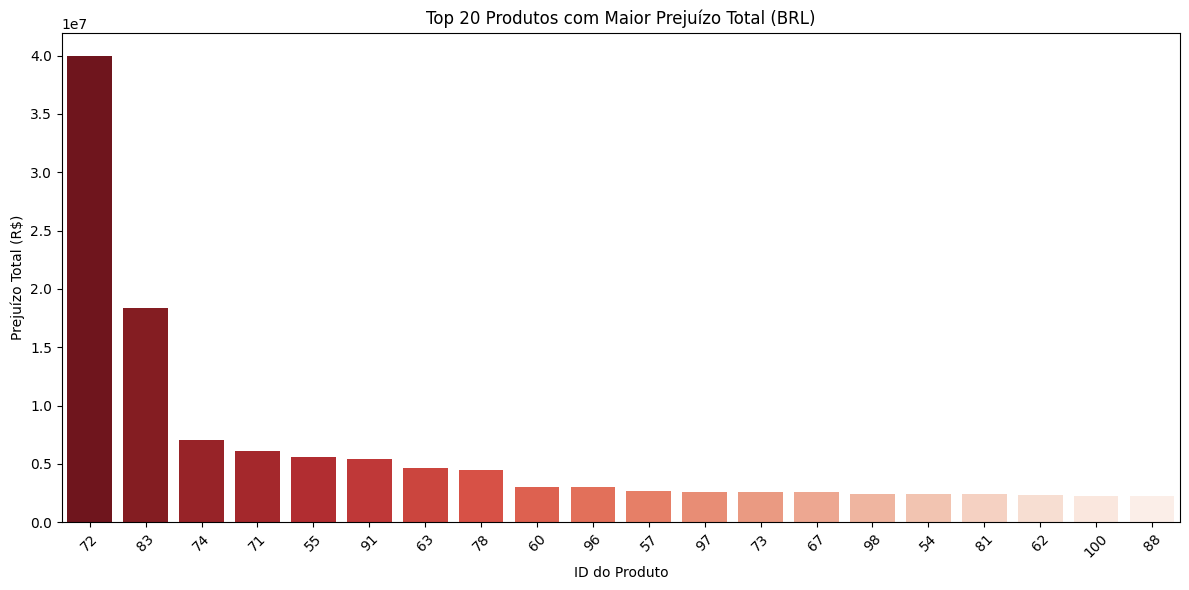

In [ ]:
# Parte 2 - Gráfico dos 20 produtos com MAIOR prejuízo
df_prejuizo = df_agg[df_agg['prejuizo_total'] > 0].sort_values(by='prejuizo_total', ascending=False).head(20)
df_prejuizo['id_product_str'] = df_prejuizo['id_product'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_prejuizo, x='id_product_str', y='prejuizo_total', hue='id_product_str', palette='Reds_r', legend=False)
plt.title('Top 20 Produtos com Maior Prejuízo Total (BRL)')
plt.xlabel('ID do Produto')
plt.ylabel('Prejuízo Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## Questão 4.1 - Código SQL
### Reconstruindo o Cálculo de Perdas e Câmbio do Pandas para DuckDB

In [ ]:
# Utilizando DuckDB para refazer o cálculo da Questão 4
import duckdb

# As variáveis vendas, custos e df_ptax já estão carregadas e tratadas nas células anteriores (Q4).
# O DuckDB compreende nativamente DataFrames Pandas armazenados na memória!

query_q4 = """
WITH ptax_prep AS (
    -- Para cada venda, puxar o câmbio mais recente inferior ou igual à data de venda
    SELECT 
        v.id_product,
        v.sale_date_dt,
        v.qtd,
        v.total AS receita_brl,
        (SELECT p.cotacaoVenda 
         FROM df_ptax p 
         WHERE p.data_ptax <= v.sale_date_dt 
         ORDER BY p.data_ptax DESC LIMIT 1) AS taxa_cambio_data,
        (SELECT c.usd_price 
         FROM custos c 
         WHERE c.id_product = v.id_product AND c.start_date_dt <= v.sale_date_dt 
         ORDER BY c.start_date_dt DESC LIMIT 1) AS custo_usd
    FROM vendas v
),
calculo_custo AS (
    -- Cálculo do custo total da transação em BRL
    SELECT 
        id_product,
        receita_brl,
        custo_usd,
        taxa_cambio_data,
        (qtd * custo_usd * taxa_cambio_data) AS custo_total_brl
    FROM ptax_prep
),
calculo_prejuizo AS (
    -- Identificação de transações com prejuízo (custo em BRL > valor de venda em BRL)
    SELECT 
        id_product,
        receita_brl,
        CASE 
            WHEN custo_total_brl > receita_brl THEN (custo_total_brl - receita_brl)
            ELSE 0 
        END AS prejuizo
    FROM calculo_custo
)
-- Agregação solicitada
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) / SUM(receita_brl)) AS percentual_perda
FROM calculo_prejuizo
GROUP BY id_product
ORDER BY prejuizo_total DESC;
"""

resultado_sql_q4 = duckdb.query(query_q4).to_df()

display(resultado_sql_q4.head(10))

,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,3.995969e+07,0.633699
1,83,44377440.00,1.838238e+07,0.414228
2,74,59764356.15,7.004602e+06,0.117204
3,71,81567066.65,6.120380e+06,0.075035
4,55,61224375.00,5.597894e+06,0.091432
5,91,66829268.70,5.396483e+06,0.080750
6,63,68817185.90,4.614028e+06,0.067048
7,78,58043733.35,4.500948e+06,0.077544
8,60,53418532.00,3.035103e+06,0.056817
9,96,27227868.90,2.985539e+06,0.109650


## Código para colar na questão 4.1

In [ ]:
WITH preparacao_taxas AS (
    -- Etapa 1: Puxar e vincular o custo em USD e a Taxa de Câmbio em relação a Data da Venda
    SELECT 
        v.id_product,
        v.qtd,
        v.total AS receita_brl,
        
        -- Garante a taxa de câmbio do dia (ou dia útil imediatamente anterior)
        (SELECT c.cotacaoVenda 
         FROM taxa_cambio c 
         WHERE c.data_cotacao <= v.sale_date 
         ORDER BY c.data_cotacao DESC LIMIT 1) AS taxa_cambio_data,
         
        -- Garante o valor de importação adequado para a linha do tempo daquela venda
        (SELECT i.usd_price 
         FROM custos_importacao i 
         WHERE i.product_id = v.id_product AND i.start_date <= v.sale_date 
         ORDER BY i.start_date DESC LIMIT 1) AS custo_usd
         
    FROM vendas_2023_2024 v
),
calculo_custo AS (
    -- Etapa 2: Cálculo total em Reais
    SELECT 
        id_product,
        receita_brl,
        (qtd * custo_usd * taxa_cambio_data) AS custo_total_brl
    FROM preparacao_taxas
),
calculo_prejuizo AS (
    -- Etapa 3: Isolar os prejuízos financeiros em transações deficitárias
    SELECT 
        id_product,
        receita_brl,
        CASE 
            WHEN custo_total_brl > receita_brl THEN (custo_total_brl - receita_brl)
            ELSE 0 
        END AS prejuizo
    FROM calculo_custo
)
-- Etapa Final: Agregação por Produto, conforme solicitado
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) / SUM(receita_brl)) AS percentual_perda
FROM calculo_prejuizo
GROUP BY id_product
ORDER BY percentual_perda DESC;


## Questão 4.2 - Validação

Qual é o id_produto que apresentou a maior porcentagem de perda financeira relativa (maior % de prejuízo sobre sua receita) no período analisado?

**Resposta**:O produto que apresentou a maior porcentagem de perda financeira relativa no período analisado foi o ID 72. Ele reteve uma taxa de perda percentual de aproximadamente 63,37%, somando um prejuízo cru na casa dos R$ 39,9 milhões contra uma receita bruta total de apenas R$ 63,0 milhões!

### Questão 4.3 - Interpretação

**1. Qual data de câmbio você utilizou?**
Utilizamos as datas de fechamento PTAX Venda da API Olinda (Banco Central do Brasil) cobrindo todo o período de vendas (2023 a 2024). Para transações ocorridas em finais de semana ou feriados (dias sem cotação bancária), utilizamos um *backward merge* (`pd.merge_asof(direction='backward')`), ou seja, o algoritmo assumiu a **última cotação válida imediatamente anterior à venda** (ex: venda no Sábado usa o PTAX de Sexta).

**2. Como definiu o prejuízo?**
O prejuízo real existe apenas quando o **Custo Total em BRL excede a Receita Total da transação (`total`)**.
- Custo Total em BRL foi calculado pela fórmula: `Quantidade Registrada * Custo Unitário em USD Histórico * Taxa Cambial PTAX Média de Venda do Dia`.
- Para transações onde Custo > Receita, subtraímos a Receita do Custo para obter exatamente o delta negativo (valor do prejuízo). Se for uma venda lucrativa, a métrica isolada de "prejuízo" dessa transação é considerada 0. A métrica global de "Prejuízo Total" agregou a soma crua desses deltas numéricos por produto.

**3. Algumas suposições relevantes?**
- Como a tabela `custos_importacao.csv` tinha o preço unitário atrelado a uma "Data_Inicio", utilizei novamente a lógica de *Backward Merge* com a data da venda para identificar qual era exatamente o custo em dólar no momento exato em que a venda foi executada, protegendo a análise de mudanças de preço de importação no intermédio dos anos de 2023 e 2024.
- Foi ignorado qualquer aspecto de inflação sobre o BRL e retenção de impostos/fretes (considerado apenas preço direto de importação e custo de venda).
